# $$ Naive Bayes $$

Let,

$$
X=\{x_1,x_2,x_3,\ldots,x_n\}
$$

$$
C=\{c_1,c_2,c_3,\ldots,c_k\}
$$

We want to calculate

$$
P(C_k|X)
$$

Using Bayes' Theorem,

$$
P(C_k|X)=\frac{P(X|C_k)P(C_k)}{P(X)}
$$

Since $P(X)$ is constant for all classes,

$$
P(C_k|X)\propto P(X|C_k)P(C_k)
$$

---

# Chain Rule

Using the chain rule,

$$
P(C_k|X)=P(X,C_k)
$$

Applying the chain rule,

$$
P(X,C_k)=P(x_1|x_2,x_3,\ldots,x_n,C_k)\;P(x_2,x_3,\ldots,x_n,C_k)
$$

Again,

$$
P(x_2,x_3,\ldots,x_n,C_k)
=
P(x_2|x_3,x_4,\ldots,x_n,C_k)\;
P(x_3,\ldots,x_n,C_k)
$$

Again,

$$
P(x_3,\ldots,x_n,C_k)
=
P(x_3|x_4,x_5,\ldots,x_n,C_k)\;
P(x_4,\ldots,x_n,C_k)
$$

Continuing,

$$
\begin{aligned}
P(X,C_k)=&
P(x_1|x_2,\ldots,x_n,C_k)
P(x_2|x_3,\ldots,x_n,C_k)\\
&\times
P(x_3|x_4,\ldots,x_n,C_k)
\cdots
P(x_{n-1}|x_n,C_k)
P(x_n|C_k)
P(C_k)
\end{aligned}
$$

Therefore,

$$
\begin{aligned}
P(C_k|X)\propto&
P(x_1|x_2,\ldots,x_n,C_k)
P(x_2|x_3,\ldots,x_n,C_k)\\
&\times
P(x_3|x_4,\ldots,x_n,C_k)
\cdots
P(x_{n-1}|x_n,C_k)
P(x_n|C_k)
P(C_k)
\end{aligned}
$$

---

# Conditional Independence (Naive Assumption)

Naive Bayes assumes that all features are conditionally independent given the class.

$$
P(x_i|x_1,\ldots,x_{i-1},x_{i+1},\ldots,x_n,C_k)
=
P(x_i|C_k)
$$

Therefore,

$$
P(X|C_k)=\prod_{i=1}^{n}P(x_i|C_k)
$$

Finally,

$$
P(C_k|X)
\propto
P(C_k)
\prod_{i=1}^{n}P(x_i|C_k)
$$

The predicted class is

$$
\hat{C}
=
\underset{C_k}{\operatorname{argmax}}
\left[
P(C_k)
\prod_{i=1}^{n}P(x_i|C_k)
\right]
$$

- # This is called maximum a postionion Rule

In [19]:
import numpy as np
import pandas as pd

In [20]:
df = pd.read_csv("/run/media/darshchouhan/New Volume/ML-Algorithm/play_tennis.csv")

In [21]:
df.head()

,day,outlook,temp,humidity,wind,play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [22]:
df.shape

(14, 6)

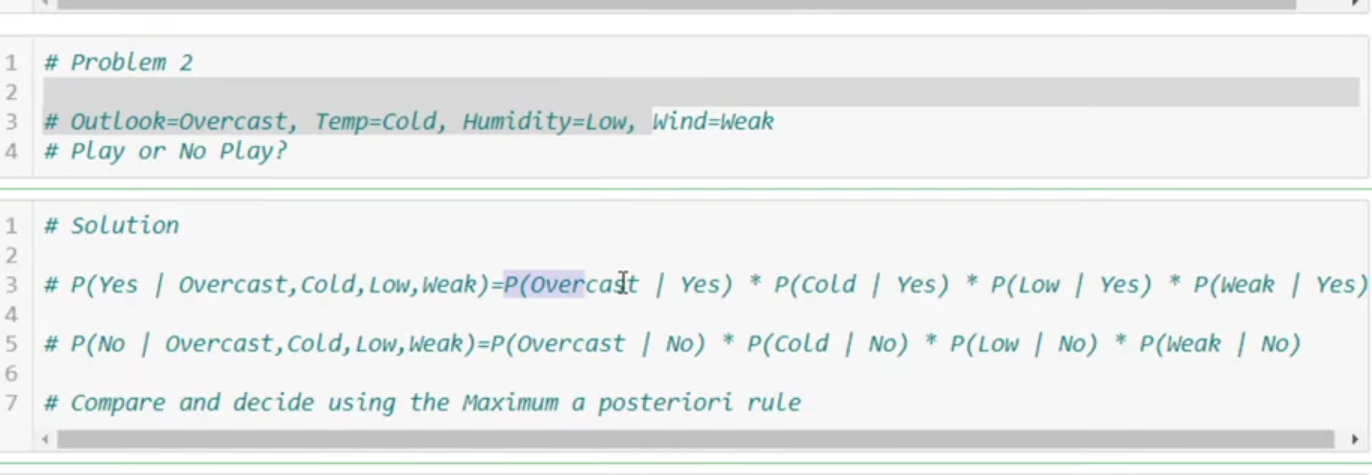

### in the training phase all the possible probalities are calculated and  stored like it will  create a lookup table in which probabilities are stored

In [23]:
df['play'].value_counts()

play
Yes    9
No     5
Name: count, dtype: int64

In [24]:
py = 9/14
pn = 5/14

In [25]:
print(py)
print(pn)

0.6428571428571429
0.35714285714285715


In [26]:
pd.crosstab(df['outlook'],df['play'])

play,No,Yes
outlook,,
Overcast,0,4
Rain,2,3
Sunny,3,2


In [27]:
Oon=0
Orn=2/5
Osn=3/5
Ooy=4/9
Ory=3/9
Osy=2/9


In [28]:
pd.crosstab(df['temp'],df['play'])

play,No,Yes
temp,,
Cool,1,3
Hot,2,2
Mild,2,4


In [29]:
Tcn=1/5
Thn=2/5
Tmn=2/5
Tcy=3/9
Thy=2/9
Tmy=4/9

In [30]:
pd.crosstab(df['humidity'],df['play'])

play,No,Yes
humidity,,
High,4,3
Normal,1,6


In [31]:
Hhn=4/5
Hnn=1/5
Hhy=3/9
Hny=6/9

In [32]:
pd.crosstab(df['wind'],df['play'])

play,No,Yes
wind,,
Strong,3,3
Weak,2,6


In [33]:
Wsn=3/5
Wwn=2/5
Wsy=3/9
Wwy=6/9

In [34]:
# Outlook su temp=Hot,Humidity=High,Wind=weak
Pyes=py*Osy*Thy*Hhy*Wwy
Pno=pn*Osn*Thn*Hhn*Wwn
print(Pyes)
print(Pno)



0.007054673721340388
0.02742857142857143


In [ ]:
# No

# Naive Bayes for the Numerical Data

# Example Dataset

Given,

$$
H = 185,\quad W = 170,\quad G = ?
$$

| Height | Weight | Gender |
|:------:|:------:|:------:|
| 172 | 150 | M |
| 180 | 170 | M |
| 165 | 140 | M |
| 190 | ? | M |
| 139| 100 | F |
| 145 | 120 | F |
| 160 | 140 | F |
| 172 | 150 | F |

We want to predict the gender for the person with

$$
H = 185,\qquad W = 170
$$

That is, we need to compare

$$
P(M \mid H=185,\;W=170)
$$

and

$$
P(F \mid H=185,\;W=170)
$$
$$
\text{most of the time that  particular  hight will not be present so its probability will become 0}
$$
$$
\text{So we assume Height  to be a gaussian Distributed Random variable, So we will calculate the mean and the sd }
$$
$$
f(x)=\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
$$
$$
\text{So we substitue the value of } \sigma,\mu \text{ and y to get the probabily note will consoder all those hights that are predicted as male}

$$

Using Naive Bayes,

$$
P(M \mid H,W)
\propto
P(M)\times P(H\mid M)\times P(W\mid M)
$$

Similarly,

$$
P(F \mid H,W)
\propto
P(F)\times P(H\mid F)\times P(W\mid F)
$$`

Finally,

$$
\hat{G}
=
\underset{G\in\{M,F\}}{\operatorname{argmax}}
\left[
P(G)\times P(H\mid G)\times P(W\mid G)
\right]
$$